<a href="https://colab.research.google.com/github/AKSHAYAVISWA/HexaTraining/blob/main/June%2017/EDA_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder.appName("EDA").getOrCreate()

appointments_data = [
 (1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
 (1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
 (1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
 (1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
 (1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
 (1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
 (1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
 (1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
 (1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
 (1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
 (1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
 (1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
 (1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
 (1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
 (1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]

columns = [
    "appointment_id",
    "city",
    "department",
    "hospital",
    "consultation_fee",
    "status"
]

df = spark.createDataFrame(appointments_data, columns)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

pdf = df.toPandas()

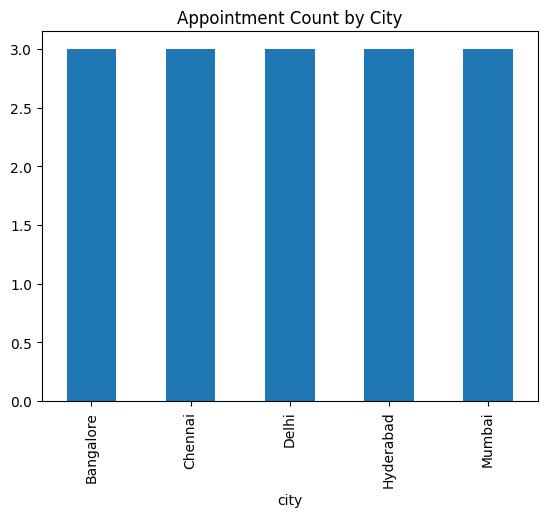

In [25]:
pdf.groupby("city").size().plot(kind="bar")
plt.title("Appointment Count by City")
plt.show()

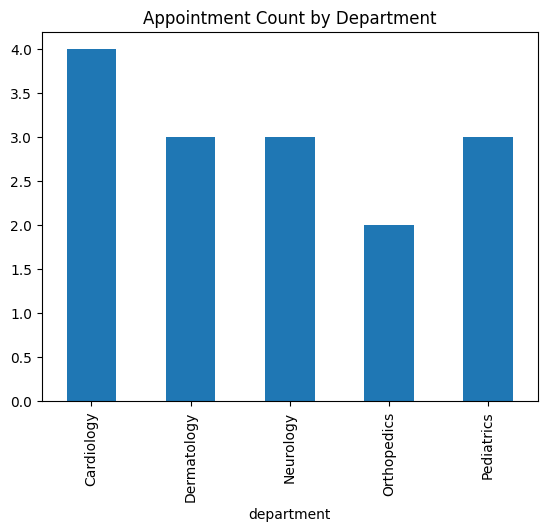

In [26]:
pdf.groupby("department").size().plot(kind="bar")
plt.title("Appointment Count by Department")
plt.show()

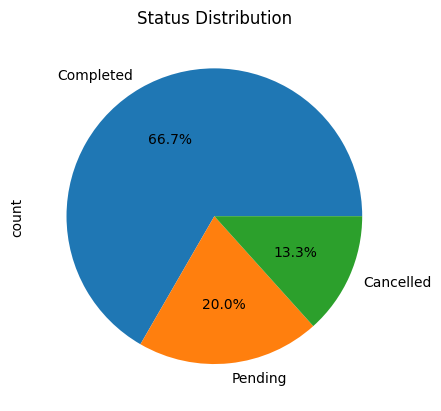

In [27]:
pdf["status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Status Distribution")
plt.show()

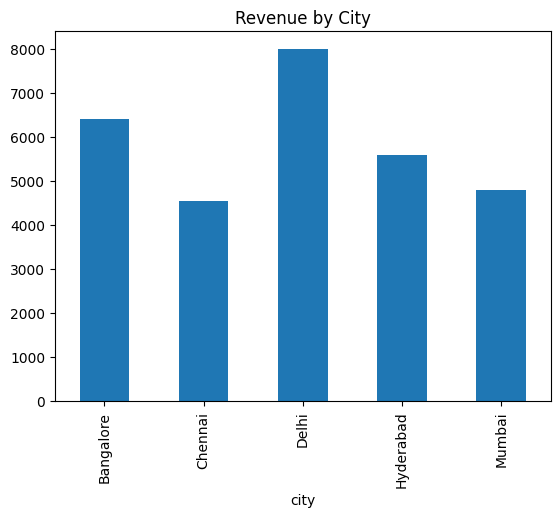

In [28]:
pdf.groupby("city")["consultation_fee"].sum().plot(kind="bar")
plt.title("Revenue by City")
plt.show()

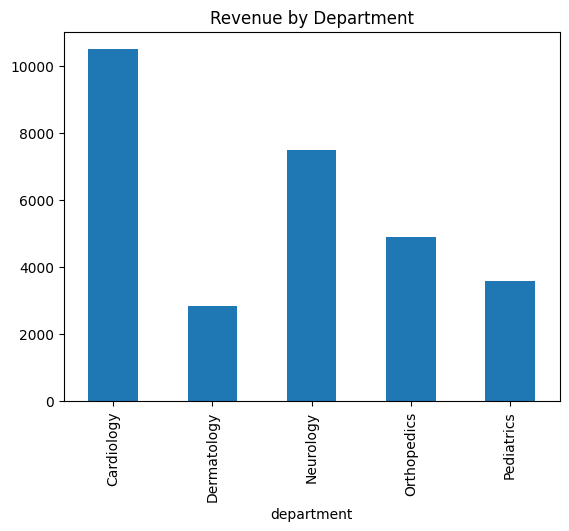

In [29]:
pdf.groupby("department")["consultation_fee"].sum().plot(kind="bar")
plt.title("Revenue by Department")
plt.show()

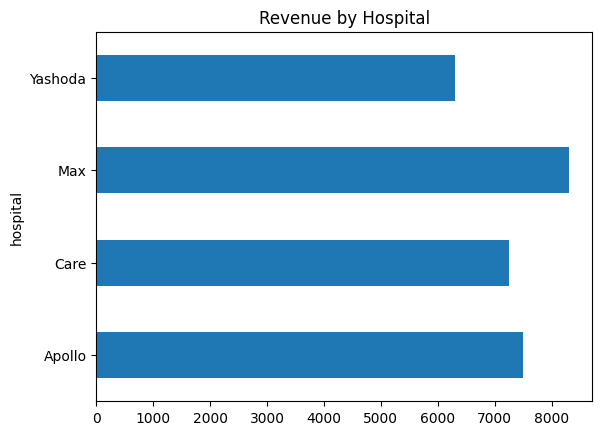

In [30]:
pdf.groupby("hospital")["consultation_fee"].sum().plot(kind="barh")
plt.title("Revenue by Hospital")
plt.show()

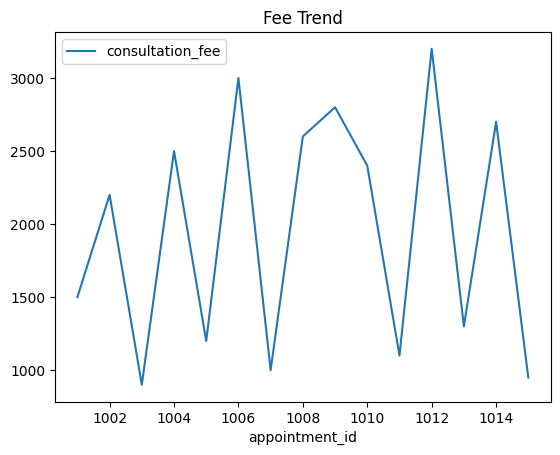

In [31]:
pdf.sort_values("appointment_id").plot(
    x="appointment_id",
    y="consultation_fee",
    kind="line"
)
plt.title("Fee Trend")
plt.show()

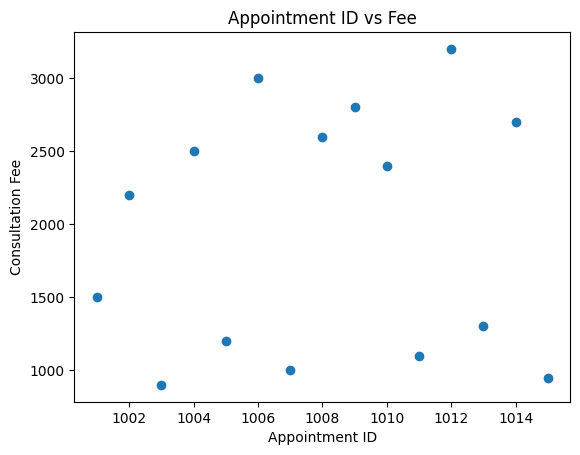

In [32]:
plt.scatter(
    pdf["appointment_id"],
    pdf["consultation_fee"]
)
plt.title("Appointment ID vs Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

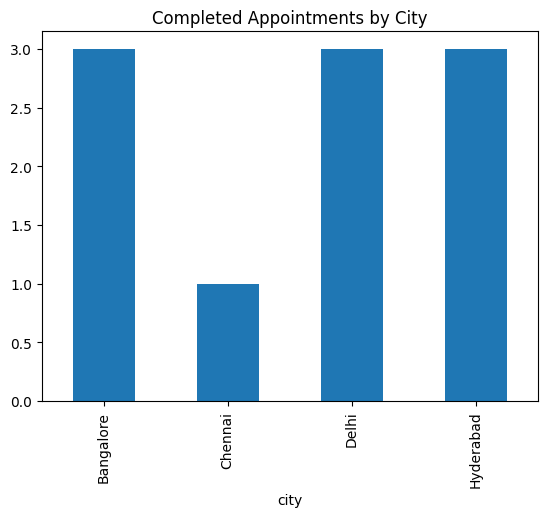

In [33]:
completed = pdf[pdf["status"] == "Completed"]

completed.groupby("city").size().plot(kind="bar")
plt.title("Completed Appointments by City")
plt.show()

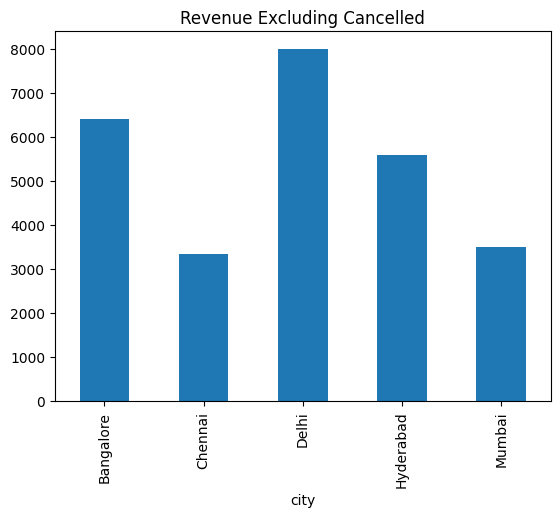

In [34]:
active = pdf[pdf["status"] != "Cancelled"]

active.groupby("city")["consultation_fee"].sum().plot(kind="bar")
plt.title("Revenue Excluding Cancelled")
plt.show()

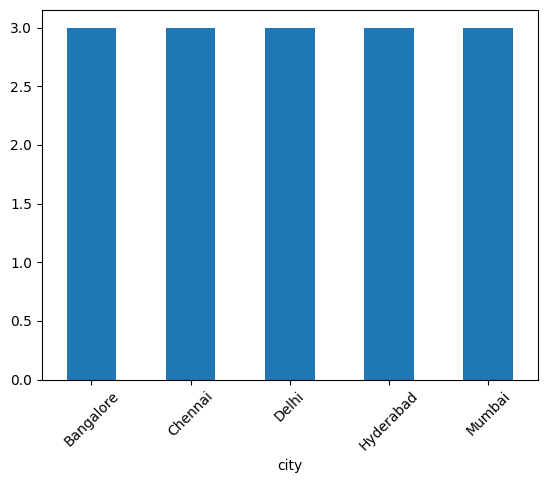

In [35]:
pdf.groupby("city").size().plot(kind="bar")
plt.xticks(rotation=45)
plt.show()

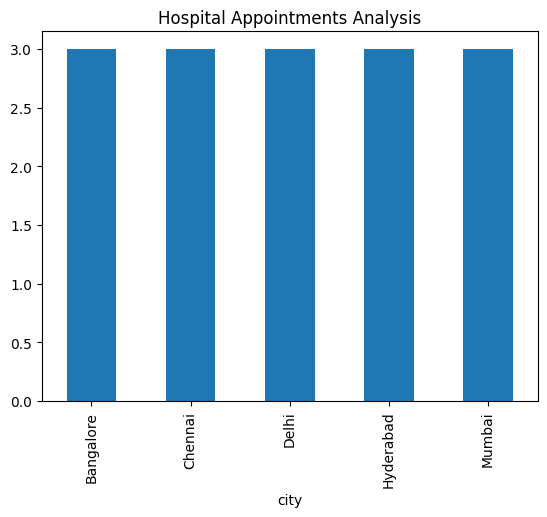

In [36]:
pdf.groupby("city").size().plot(kind="bar")
plt.title("Hospital Appointments Analysis")
plt.show()

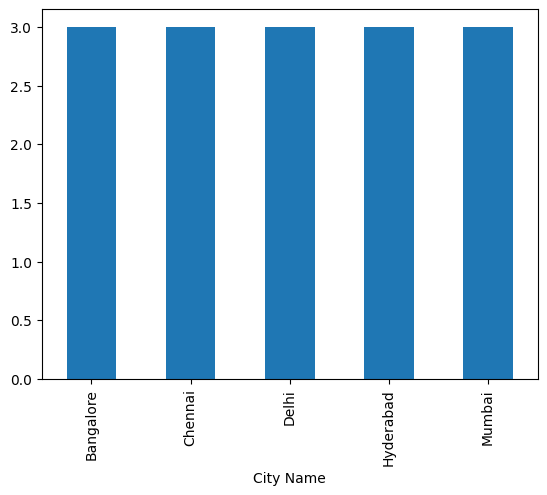

In [37]:
pdf.groupby("city").size().plot(kind="bar")
plt.xlabel("City Name")
plt.show()

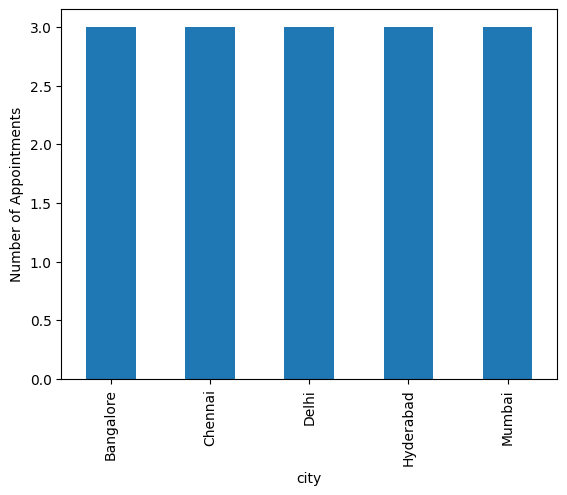

In [38]:
pdf.groupby("city").size().plot(kind="bar")
plt.ylabel("Number of Appointments")
plt.show()

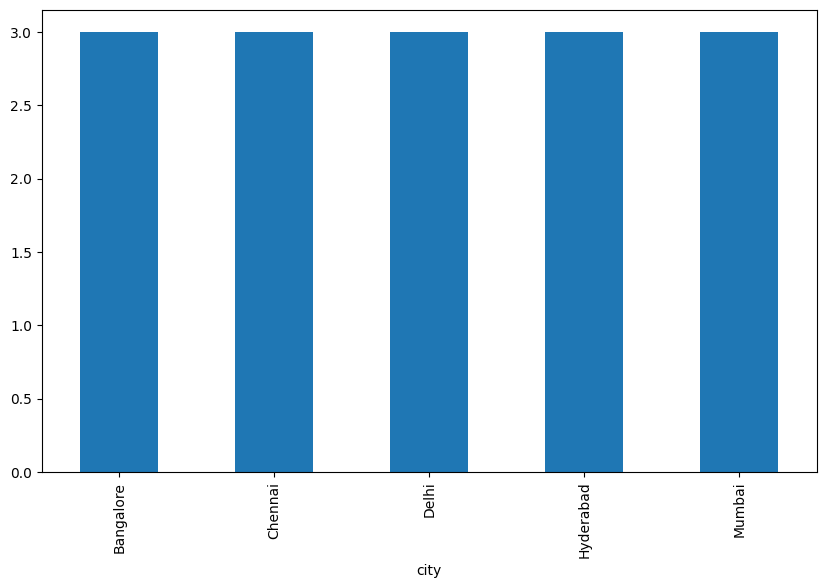

In [39]:
plt.figure(figsize=(10,6))
pdf.groupby("city").size().plot(kind="bar")
plt.show()

In [40]:
top3_cities = pdf.groupby("city")["consultation_fee"] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(3)

print(top3_cities)

city
Delhi        8000
Bangalore    6400
Hyderabad    5600
Name: consultation_fee, dtype: int64


In [41]:
top3_dept = pdf.groupby("department")["consultation_fee"] \
               .sum() \
               .sort_values(ascending=False) \
               .head(3)

print(top3_dept)

department
Cardiology     10500
Neurology       7500
Orthopedics     4900
Name: consultation_fee, dtype: int64


In [42]:
lowest = pdf.groupby("hospital")["consultation_fee"] \
            .sum() \
            .sort_values() \
            .head(1)

print(lowest)

hospital
Yashoda    6300
Name: consultation_fee, dtype: int64


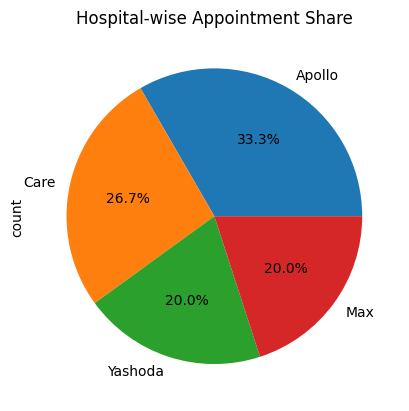

In [22]:
pdf["hospital"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Hospital-wise Appointment Share")
plt.show()

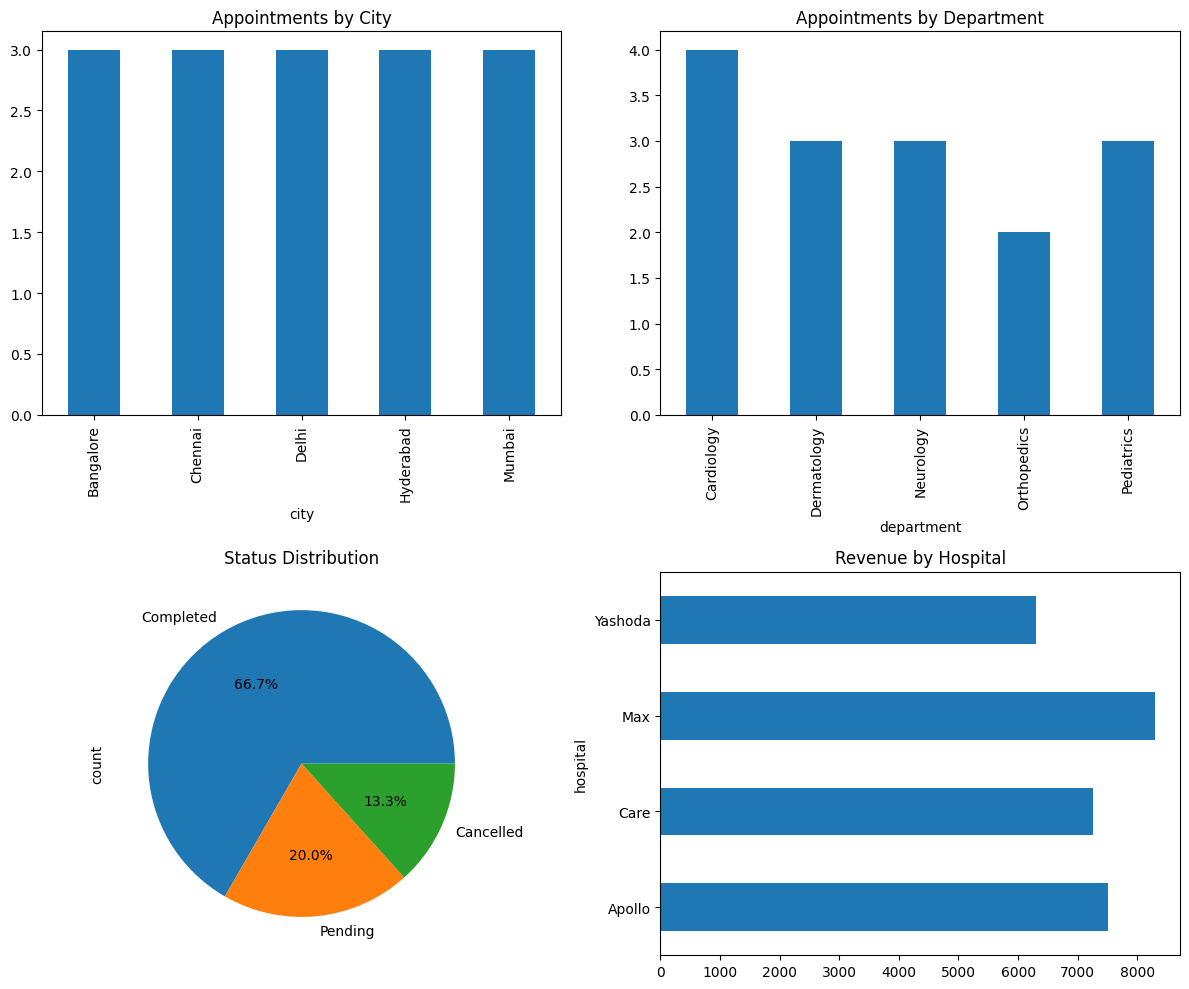

In [43]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
pdf.groupby("city").size().plot(kind="bar")
plt.title("Appointments by City")

plt.subplot(2,2,2)
pdf.groupby("department").size().plot(kind="bar")
plt.title("Appointments by Department")

plt.subplot(2,2,3)
pdf["status"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Status Distribution")

plt.subplot(2,2,4)
pdf.groupby("hospital")["consultation_fee"].sum().plot(kind="barh")
plt.title("Revenue by Hospital")

plt.tight_layout()
plt.show()